# ShopSphere EDA — silver layer

First-look exploratory analysis of the cleaned (silver) data. Figures are
saved to `reports/figures/`. Metric definitions mirror
`python/01_generate/calibration_check.py` so numbers here are comparable to
the calibration report: revenue = `quantity * unit_price_at_sale - line_discount`,
restricted to `completed` orders.

Run headlessly: executed via `nbclient` as part of the P3 build; re-run any
time with *Run All* — no cell depends on external state beyond `data/silver/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists():
    ROOT = ROOT.parent
SILVER = ROOT / 'data' / 'silver'
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY = '#1f77b4', '#d62728', '#7f7f7f'

customers = pd.read_csv(SILVER / 'customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv(SILVER / 'orders.csv', parse_dates=['order_ts'])
items = pd.read_csv(SILVER / 'order_items.csv')
sessions = pd.read_csv(SILVER / 'web_sessions.csv', usecols=['session_id'])
events = pd.read_csv(SILVER / 'web_events.csv', usecols=['event_type'])
spend = pd.read_csv(SILVER / 'marketing_spend.csv', parse_dates=['spend_date'])
reviews = pd.read_csv(SILVER / 'reviews_nps.csv')

line_rev = items['quantity'] * items['unit_price_at_sale'] - items['line_discount']
order_rev = line_rev.groupby(items['order_id']).sum().rename('revenue')
completed = orders[orders['order_status'] == 'completed'].join(order_rev, on='order_id')

print(f"{len(customers):,} customers | {len(orders):,} orders "
      f"({len(completed):,} completed) | {len(sessions):,} sessions")
print(f"orders span {orders['order_ts'].min():%Y-%m-%d} .. {orders['order_ts'].max():%Y-%m-%d}")
print(f"completed revenue total ${completed['revenue'].sum():,.0f}")

12,000 customers | 19,397 orders (17,811 completed) | 800,000 sessions
orders span 2024-06-07 .. 2026-06-30
completed revenue total $1,664,813


## 1. Monthly revenue and seasonality

Completed revenue by month; November–December (holiday season) highlighted.
The generator targets a 1.35–2.10x Nov–Dec daily-revenue multiplier.

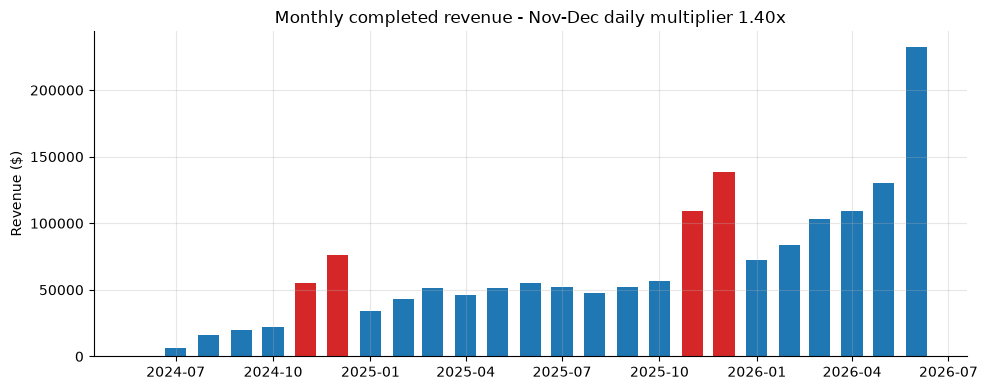

Nov-Dec daily revenue multiplier: 1.405


In [2]:
monthly = completed.set_index('order_ts')['revenue'].resample('MS').sum()
daily = completed.set_index('order_ts')['revenue'].resample('D').sum()
season_mult = daily[daily.index.month.isin([11, 12])].mean() / daily.mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if m in (11, 12) else BLUE for m in monthly.index.month]
ax.bar(monthly.index, monthly.values, width=20, color=colors)
ax.set_title(f'Monthly completed revenue - Nov-Dec daily multiplier {season_mult:.2f}x')
ax.set_ylabel('Revenue ($)')
fig.tight_layout()
fig.savefig(FIG / 'monthly_revenue.png', bbox_inches='tight')
plt.show()
print(f'Nov-Dec daily revenue multiplier: {season_mult:.3f}')

## 2. Order value distribution (AOV)

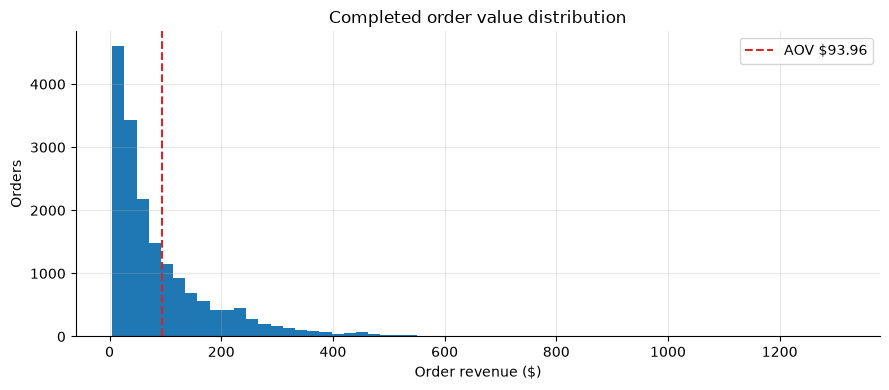

AOV (completed): $93.96 | median $56.06


In [3]:
aov = completed['revenue'].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(completed['revenue'].dropna(), bins=60, color=BLUE)
ax.axvline(aov, color=RED, ls='--', lw=1.5, label=f'AOV ${aov:,.2f}')
ax.set_title('Completed order value distribution')
ax.set_xlabel('Order revenue ($)')
ax.set_ylabel('Orders')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'aov_distribution.png', bbox_inches='tight')
plt.show()
print(f'AOV (completed): ${aov:,.2f} | median ${completed["revenue"].median():,.2f}')

## 3. Conversion funnel

Event counts by funnel stage with step-to-step conversion. Cart abandonment
= 1 − purchase/add_to_cart.

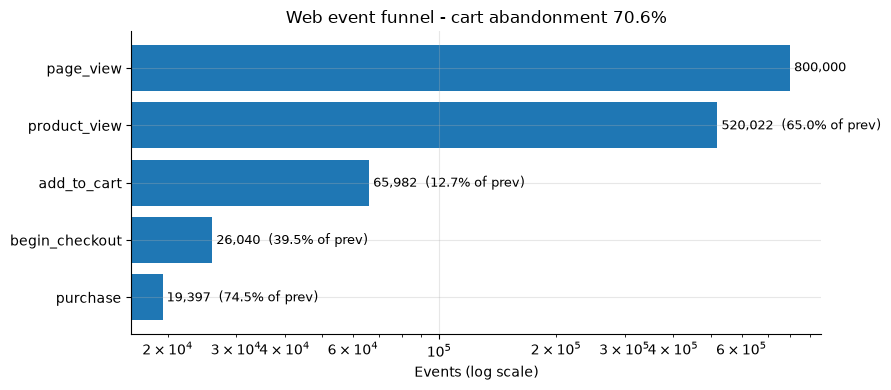

cart abandonment 0.706 | session->order conversion 0.0242


In [4]:
stages = ['page_view', 'product_view', 'add_to_cart', 'begin_checkout', 'purchase']
counts = events['event_type'].value_counts().reindex(stages)
abandon = 1 - counts['purchase'] / counts['add_to_cart']

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(stages[::-1], counts[::-1], color=BLUE)
for i, stage in enumerate(stages[::-1]):
    n = counts[stage]
    label = f'{n:,.0f}'
    idx = stages.index(stage)
    if idx > 0:
        label += f'  ({n / counts[stages[idx - 1]]:.1%} of prev)'
    ax.text(n, i, ' ' + label, va='center', fontsize=9)
ax.set_xscale('log')
ax.set_title(f'Web event funnel - cart abandonment {abandon:.1%}')
ax.set_xlabel('Events (log scale)')
fig.tight_layout()
fig.savefig(FIG / 'funnel_conversion.png', bbox_inches='tight')
plt.show()
print(f'cart abandonment {abandon:.3f} | session->order conversion '
      f'{len(orders) / len(sessions):.4f}')

## 4. Customer revenue concentration (Pareto)

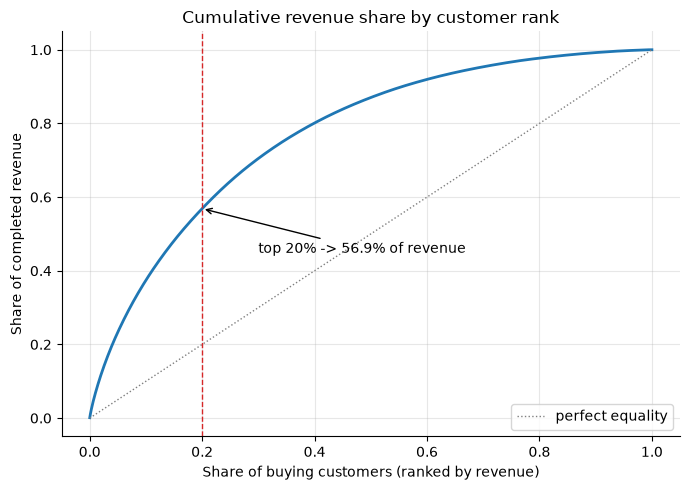

top-20% revenue share: 0.569


In [5]:
cust_rev = (completed.groupby('customer_id')['revenue'].sum()
            .sort_values(ascending=False))
cum_share = cust_rev.cumsum() / cust_rev.sum()
x = np.arange(1, len(cum_share) + 1) / len(cum_share)
top20 = cum_share.iloc[int(len(cum_share) * 0.2) - 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, cum_share.values, color=BLUE, lw=2)
ax.plot([0, 1], [0, 1], color=GRAY, ls=':', lw=1, label='perfect equality')
ax.axvline(0.2, color=RED, ls='--', lw=1)
ax.annotate(f'top 20% -> {top20:.1%} of revenue', xy=(0.2, top20),
            xytext=(0.3, top20 - 0.12), arrowprops={'arrowstyle': '->'})
ax.set_title('Cumulative revenue share by customer rank')
ax.set_xlabel('Share of buying customers (ranked by revenue)')
ax.set_ylabel('Share of completed revenue')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'customer_pareto.png', bbox_inches='tight')
plt.show()
print(f'top-20% revenue share: {top20:.3f}')

## 5. Acquisition cost by channel

Spend per acquired customer, per channel with recorded marketing spend.
Channels without spend rows (e.g. organic) have no CAC by definition.

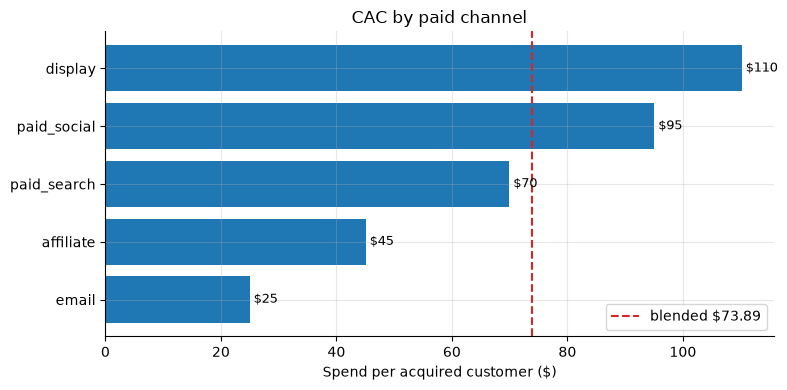

blended paid CAC: $73.89 across ['affiliate', 'display', 'email', 'paid_search', 'paid_social']


In [6]:
ch_spend = spend.groupby('channel')['spend_amount'].sum()
ch_cust = customers.groupby('acquisition_channel').size()
cac = (ch_spend / ch_cust).dropna().sort_values()
blended = ch_spend.sum() / ch_cust.reindex(ch_spend.index).sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cac.index, cac.values, color=BLUE)
ax.axvline(blended, color=RED, ls='--', lw=1.5, label=f'blended ${blended:,.2f}')
for i, v in enumerate(cac.values):
    ax.text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
ax.set_title('CAC by paid channel')
ax.set_xlabel('Spend per acquired customer ($)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'cac_by_channel.png', bbox_inches='tight')
plt.show()
print(f'blended paid CAC: ${blended:,.2f} across {list(ch_spend.index)}')

## 6. Repeat purchase behaviour

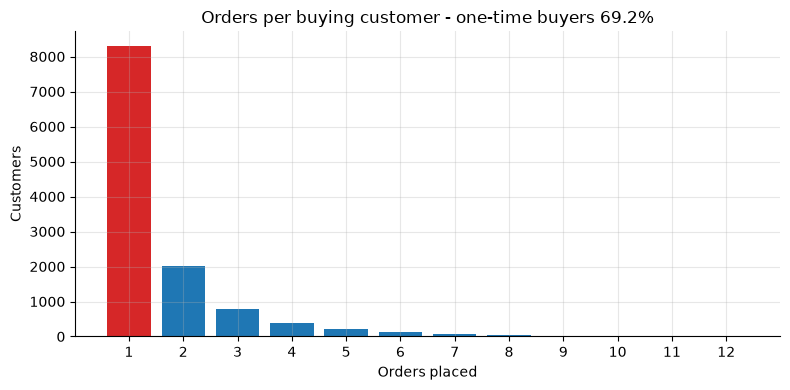

one-time buyer share: 0.692 | max orders: 12


In [7]:
per_cust = orders.groupby('customer_id').size()
one_time = (per_cust == 1).mean()
dist = per_cust.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color=[RED if k == 1 else BLUE for k in dist.index])
ax.set_title(f'Orders per buying customer - one-time buyers {one_time:.1%}')
ax.set_xlabel('Orders placed')
ax.set_ylabel('Customers')
ax.set_xticks(dist.index)
fig.tight_layout()
fig.savefig(FIG / 'repeat_purchase.png', bbox_inches='tight')
plt.show()
print(f'one-time buyer share: {one_time:.3f} | max orders: {per_cust.max()}')

## Summary

Key figures land inside every calibration target band (see
`docs/calibration_report.md`); the cell below prints the headline numbers
computed from silver data for quick comparison.

**Observation:** the final month (2026-06) shows completed orders 65% above
May (2,350 vs 1,428). Weekly counts ramp smoothly within June (392, 465,
503, 677), continuing May's trajectory — this is the generator's
accelerating growth curve steepening at the end of the 24-month window, not
a data defect. Worth keeping in mind when quoting recent-month growth.

In [8]:
print(f'AOV (completed)          ${aov:,.2f}')
print(f'One-time buyer share      {one_time:.1%}')
print(f'Cart abandonment          {abandon:.1%}')
print(f'Top-20% revenue share     {top20:.1%}')
print(f'Nov-Dec daily multiplier  {season_mult:.2f}x')
print(f'Blended paid CAC          ${blended:,.2f}')
print(f'NPS mean                  {reviews["nps_score"].mean():.2f} | '
      f'star mean {reviews["star_rating"].mean():.2f}')
print('figures ->', sorted(p.name for p in FIG.glob('*.png')))

AOV (completed)          $93.96
One-time buyer share      69.2%
Cart abandonment          70.6%
Top-20% revenue share     56.9%
Nov-Dec daily multiplier  1.40x
Blended paid CAC          $73.89
NPS mean                  8.20 | star mean 4.05
figures -> ['aov_distribution.png', 'cac_by_channel.png', 'customer_pareto.png', 'funnel_conversion.png', 'monthly_revenue.png', 'repeat_purchase.png']
